# Notebook 05: Fairness Analysis & Calibration Curves
## Wearable-Enhanced Insurance Underwriting — NHANES 2003-2004

**Author:** Lubaba Hassan | 22097014D | PolyU Data Science and Analytics

This notebook addresses **RQ3** — which classifier/scenario combination best balances
predictive performance, interpretability, and **demographic fairness** — and adds
**calibration curves** (critical for insurance pricing context).

### Contents
1. Load data and retrain best models per scenario
2. Fairness analysis: AUC and FPR by gender and age band
3. Disparate Impact Ratio (80% rule)
4. Calibration curves (reliability diagrams) — Scenario A vs B
5. Combined fairness–performance summary table
6. Key findings for report

### Why This Matters for Insurance
- **Fairness**: Regulators increasingly require that ML-based underwriting does not
  disproportionately penalise protected groups. A model with high overall AUC but
  systematically higher false-positive rates for younger applicants would generate
  unfair premium loadings.
- **Calibration**: Insurers price premiums from predicted *probabilities*, not just
  classifications. A model that says "70% high-risk" must mean that ~70% of such
  applicants truly are high-risk. Poor calibration → mispriced premiums.

## 1. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    roc_auc_score, f1_score, brier_score_loss,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Paths
DATA_PATH = '../data/processed/'
FIGURES_PATH = '../reports/figures/'
RESULTS_PATH = '../results/'
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

print('All imports successful.')

All imports successful.


## 2. Load Data and Define Feature Sets

In [3]:
# Load scenario CSVs
scenario_a = pd.read_csv(DATA_PATH + 'scenario_a.csv')
scenario_b = pd.read_csv(DATA_PATH + 'scenario_b.csv')
scenario_c = pd.read_csv(DATA_PATH + 'scenario_c.csv')

print('Loaded scenarios:')
for name, df in [('A', scenario_a), ('B', scenario_b), ('C', scenario_c)]:
    print(f'  Scenario {name}: {df.shape[0]:,} rows, {df.shape[1]} cols')
    print(f'    Label distribution: {df["risk_class"].value_counts().sort_index().to_dict()}')

Loaded scenarios:
  Scenario A: 3,388 rows, 20 cols
    Label distribution: {0: 1348, 1: 703, 2: 1337}
  Scenario B: 1,887 rows, 27 cols
    Label distribution: {0: 841, 1: 381, 2: 665}
  Scenario C: 1,887 rows, 14 cols
    Label distribution: {0: 841, 1: 381, 2: 665}


In [4]:
# Feature definitions — must match Notebook 03 exactly
TRADITIONAL_FEATURES = [
    'age', 'male',
    'bmi', 'waist_cm',
    'systolic_bp', 'diastolic_bp',
    'total_cholesterol', 'hdl_cholesterol',
    'ever_smoker',
    'self_rated_health',
    'daily_activity_level',
    'high_chol_told',
    'bp_hypertension_measured'
]

WEARABLE_FEATURES = [
    'total_met_hours',
    'mean_met',
    'total_activities',
    'moderate_count',
    'vigorous_count',
    'vigorous_ratio',
    'activity_category'
]

SCENARIO_FEATURES = {
    'A': TRADITIONAL_FEATURES,
    'B': TRADITIONAL_FEATURES + WEARABLE_FEATURES,
    'C': WEARABLE_FEATURES
}

SCENARIO_DATA = {
    'A': scenario_a,
    'B': scenario_b,
    'C': scenario_c
}

LABEL_COL = 'risk_class'
CLASS_NAMES = ['Low', 'Intermediate', 'High']
N_CLASSES = 3

print('Feature counts — A:', len(SCENARIO_FEATURES['A']),
      '| B:', len(SCENARIO_FEATURES['B']),
      '| C:', len(SCENARIO_FEATURES['C']))

Feature counts — A: 13 | B: 20 | C: 7


## 3. Retrain Best Models Per Scenario

We retrain all four classifiers on each scenario using the **same split and
hyperparameters as Notebook 03** so that we have access to the fitted model
objects, predicted probabilities, and the demographic columns for the test set.

In [7]:
def get_classifiers():
    """Return the four classifiers with their best-practice defaults.
    These match Notebook 03's GridSearchCV best params broadly;
    if you saved best params from NB03, replace these."""
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=2000, class_weight='balanced',
            solver='lbfgs',
            random_state=RANDOM_STATE
        ),
        'Decision Tree': DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=10, min_samples_leaf=5,
            random_state=RANDOM_STATE
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            max_depth=15, min_samples_leaf=3,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6,
            learning_rate=0.1, subsample=0.8,
            colsample_bytree=0.8, eval_metric='mlogloss',
            use_label_encoder=False,
            random_state=RANDOM_STATE
        )
    }

print('Classifier definitions ready.')

Classifier definitions ready.


In [8]:
# ── Train all models and store predictions + metadata ────────
trained = {}  # key: (scenario, classifier_name) → dict of model, proba, y_test, meta

for scen_name, scen_df in SCENARIO_DATA.items():
    features = SCENARIO_FEATURES[scen_name]
    X = scen_df[features].copy()
    y = scen_df[LABEL_COL].copy()
    
    # Keep demographic metadata aligned with the split
    meta_cols_available = [c for c in ['male', 'age_band', 'ethnicity', 'income_cat']
                          if c in scen_df.columns]
    # 'male' is already in X for scenarios A and B; for C it's not a feature
    # We need 'male' from the original df for fairness even if not a feature
    meta = scen_df[['SEQN'] + meta_cols_available].copy()
    
    # If 'male' is not in meta (Scenario C), try to get it from scenario_a
    if 'male' not in meta.columns:
        gender_map = scenario_a[['SEQN', 'male']].drop_duplicates()
        meta = meta.merge(gender_map, on='SEQN', how='left')
    
    # If 'age_band' is not available, try to get it
    if 'age_band' not in meta.columns:
        age_map = scenario_a[['SEQN', 'age_band']].drop_duplicates()
        meta = meta.merge(age_map, on='SEQN', how='left')
    
    # Stratified split — same random_state as NB03
    X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
        X, y, meta, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    
    # Scale features for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                                  columns=features, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test),
                                 columns=features, index=X_test.index)
    
    classifiers = get_classifiers()
    
    for clf_name, clf in classifiers.items():
        # Use scaled data for LR, raw for tree-based
        if clf_name == 'Logistic Regression':
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test
        
        # XGBoost needs sample weights
        if clf_name == 'XGBoost':
            sw = compute_sample_weight('balanced', y_train)
            clf.fit(X_tr, y_train, sample_weight=sw)
        else:
            clf.fit(X_tr, y_train)
        
        y_pred = clf.predict(X_te)
        y_proba = clf.predict_proba(X_te)
        
        trained[(scen_name, clf_name)] = {
            'model': clf,
            'y_test': y_test.values,
            'y_pred': y_pred,
            'y_proba': y_proba,
            'meta_test': meta_test.reset_index(drop=True),
            'X_test': X_te
        }
    
    print(f'Scenario {scen_name}: all 4 classifiers trained (n_test={len(y_test)})')

print(f'\nTotal model configurations: {len(trained)}')

Scenario A: all 4 classifiers trained (n_test=678)
Scenario B: all 4 classifiers trained (n_test=378)
Scenario C: all 4 classifiers trained (n_test=378)

Total model configurations: 12


## 4. Fairness Analysis: AUC and FPR by Demographic Subgroup

For each model × scenario, we compute:
- **Subgroup AUC** (one-vs-rest macro) for each gender and age band
- **Subgroup FPR** (false positive rate) — the rate at which low/intermediate
  risk applicants are incorrectly flagged as high risk
- **AUC gap** and **FPR gap** — difference between best and worst subgroup

In [9]:
def compute_subgroup_metrics(y_true, y_pred, y_proba, groups, group_col_name):
    """
    Compute AUC and FPR for each subgroup defined by `groups`.
    
    FPR is defined as: among participants whose true class is NOT High (class 2),
    what fraction are predicted as High? This is the insurance-relevant FPR —
    it measures how often a model incorrectly flags someone for premium loading.
    
    Returns a list of dicts.
    """
    results = []
    unique_groups = sorted(groups.dropna().unique())
    
    for grp in unique_groups:
        mask = (groups.values == grp)
        if mask.sum() < 10:  # skip tiny subgroups
            continue
        
        y_t = y_true[mask]
        y_p = y_pred[mask]
        y_pr = y_proba[mask]
        
        # AUC (one-vs-rest, macro)
        try:
            y_bin = label_binarize(y_t, classes=[0, 1, 2])
            # Need at least 2 classes present
            if y_bin.shape[1] < 2 or len(np.unique(y_t)) < 2:
                auc = np.nan
            else:
                auc = roc_auc_score(y_bin, y_pr, multi_class='ovr', average='macro')
        except ValueError:
            auc = np.nan
        
        # FPR for "High" class: false positives / (false positives + true negatives)
        # i.e., among non-High-risk people, how many get flagged as High?
        not_high_mask = (y_t != 2)
        if not_high_mask.sum() > 0:
            fpr_high = (y_p[not_high_mask] == 2).sum() / not_high_mask.sum()
        else:
            fpr_high = np.nan
        
        # F1 macro
        try:
            f1 = f1_score(y_t, y_p, average='macro', zero_division=0)
        except:
            f1 = np.nan
        
        results.append({
            'group_type': group_col_name,
            'group': grp,
            'n': int(mask.sum()),
            'auc': auc,
            'fpr_high': fpr_high,
            'f1_macro': f1
        })
    
    return results

print('Subgroup metrics function defined.')

Subgroup metrics function defined.


In [10]:
# ── Compute fairness metrics for all model × scenario combos ──
fairness_rows = []

for (scen, clf_name), info in trained.items():
    y_true = info['y_test']
    y_pred = info['y_pred']
    y_proba = info['y_proba']
    meta = info['meta_test']
    
    # Gender subgroups
    if 'male' in meta.columns:
        gender_labels = meta['male'].map({0: 'Female', 1: 'Male'})
        gender_results = compute_subgroup_metrics(
            y_true, y_pred, y_proba, gender_labels, 'Gender'
        )
        for r in gender_results:
            r['scenario'] = scen
            r['classifier'] = clf_name
        fairness_rows.extend(gender_results)
    
    # Age band subgroups
    if 'age_band' in meta.columns:
        age_results = compute_subgroup_metrics(
            y_true, y_pred, y_proba, meta['age_band'], 'Age Band'
        )
        for r in age_results:
            r['scenario'] = scen
            r['classifier'] = clf_name
        fairness_rows.extend(age_results)

fairness_df = pd.DataFrame(fairness_rows)
print(f'Fairness metrics computed: {len(fairness_df)} rows')
print(f'Scenarios: {fairness_df["scenario"].unique()}')
print(f'Classifiers: {fairness_df["classifier"].unique()}')
print(f'Group types: {fairness_df["group_type"].unique()}')

Fairness metrics computed: 72 rows
Scenarios: <StringArray>
['A', 'B', 'C']
Length: 3, dtype: str
Classifiers: <StringArray>
['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
Length: 4, dtype: str
Group types: <StringArray>
['Gender', 'Age Band']
Length: 2, dtype: str


In [11]:
# ── Display fairness table: Gender ─────────────────────────────
print('=' * 80)
print('FAIRNESS BY GENDER')
print('=' * 80)

gender_df = fairness_df[fairness_df['group_type'] == 'Gender'].copy()
gender_pivot = gender_df.pivot_table(
    index=['scenario', 'classifier'],
    columns='group',
    values=['auc', 'fpr_high'],
    aggfunc='first'
)

# Flatten column names
gender_pivot.columns = [f'{metric}_{group}' for metric, group in gender_pivot.columns]
gender_pivot = gender_pivot.reset_index()

# Compute gaps
gender_pivot['AUC_gap'] = abs(gender_pivot['auc_Male'] - gender_pivot['auc_Female'])
gender_pivot['FPR_gap'] = abs(gender_pivot['fpr_high_Male'] - gender_pivot['fpr_high_Female'])

print(gender_pivot.to_string(index=False))

FAIRNESS BY GENDER
scenario          classifier  auc_Female  auc_Male  fpr_high_Female  fpr_high_Male  AUC_gap  FPR_gap
       A       Decision Tree      0.9319    0.8735           0.0659         0.0980   0.0584   0.0321
       A Logistic Regression      0.9110    0.8680           0.0465         0.1634   0.0430   0.1169
       A       Random Forest      0.9570    0.9495           0.0116         0.1046   0.0074   0.0929
       A             XGBoost      0.9615    0.9561           0.0116         0.1176   0.0054   0.1060
       B       Decision Tree      0.9464    0.8993           0.0336         0.1562   0.0471   0.1227
       B Logistic Regression      0.9365    0.9133           0.0738         0.0938   0.0232   0.0199
       B       Random Forest      0.9715    0.9434           0.0000         0.1771   0.0281   0.1771
       B             XGBoost      0.9679    0.9730           0.0134         0.1667   0.0052   0.1532
       C       Decision Tree      0.4746    0.5451           0.5034     

In [12]:
# ── Display fairness table: Age Band ───────────────────────────
print('=' * 80)
print('FAIRNESS BY AGE BAND')
print('=' * 80)

age_df = fairness_df[fairness_df['group_type'] == 'Age Band'].copy()
age_pivot = age_df.pivot_table(
    index=['scenario', 'classifier'],
    columns='group',
    values=['auc', 'fpr_high'],
    aggfunc='first'
)

age_pivot.columns = [f'{metric}_{group}' for metric, group in age_pivot.columns]
age_pivot = age_pivot.reset_index()

# Compute max AUC gap and max FPR gap across age bands
auc_cols = [c for c in age_pivot.columns if c.startswith('auc_')]
fpr_cols = [c for c in age_pivot.columns if c.startswith('fpr_high_')]

age_pivot['AUC_gap_max'] = age_pivot[auc_cols].max(axis=1) - age_pivot[auc_cols].min(axis=1)
age_pivot['FPR_gap_max'] = age_pivot[fpr_cols].max(axis=1) - age_pivot[fpr_cols].min(axis=1)

print(age_pivot.to_string(index=False))

FAIRNESS BY AGE BAND
scenario          classifier  auc_30-45  auc_46-60  auc_61-75  auc_76-85  fpr_high_30-45  fpr_high_46-60  fpr_high_61-75  fpr_high_76-85  AUC_gap_max  FPR_gap_max
       A       Decision Tree     0.8674     0.8621     0.9325     0.9520          0.0673          0.0619          0.1404          0.0909       0.0900       0.0784
       A Logistic Regression     0.8686     0.8596     0.9452     0.9205          0.0337          0.1327          0.0526          0.3636       0.0856       0.3300
       A       Random Forest     0.9463     0.9357     0.9678     0.9725          0.0048          0.0708          0.1053          0.1212       0.0368       0.1164
       A             XGBoost     0.9507     0.9406     0.9733     0.9717          0.0192          0.0885          0.0702          0.0909       0.0327       0.0717
       B       Decision Tree     0.9931     0.8868     0.8978     0.9792          0.0171          0.0938          0.2340          0.0588       0.1063       0.2169
 

## 5. Disparate Impact Ratio (80% Rule)

The **Disparate Impact Ratio (DIR)** measures whether a model's positive
classification rate differs substantially between demographic groups.

$$\text{DIR} = \frac{P(\hat{y} = \text{High} \mid \text{unprivileged group})}
               {P(\hat{y} = \text{High} \mid \text{privileged group})}$$

A DIR below **0.8** signals potential unfairness (EEOC 80% rule).
A DIR above **1.25** also signals unfairness (inverse direction).

We compute DIR for:
- **Gender**: Female vs Male (male as reference)
- **Age**: Each age band vs the youngest band as reference

In [13]:
def compute_disparate_impact(y_pred, groups, reference_group):
    """
    Compute Disparate Impact Ratio for predicting High risk (class 2).
    DIR = P(pred=High | group) / P(pred=High | reference_group)
    
    Returns dict of {group: DIR}
    """
    # Reference group positive rate
    ref_mask = (groups == reference_group)
    if ref_mask.sum() == 0:
        return {}
    ref_rate = (y_pred[ref_mask] == 2).sum() / ref_mask.sum()
    
    if ref_rate == 0:
        return {str(g): np.nan for g in groups.unique()}
    
    result = {}
    for grp in sorted(groups.dropna().unique()):
        grp_mask = (groups == grp)
        grp_rate = (y_pred[grp_mask] == 2).sum() / grp_mask.sum()
        result[str(grp)] = grp_rate / ref_rate
    
    return result

print('Disparate Impact function defined.')

Disparate Impact function defined.


In [14]:
# ── Compute DIR for all model × scenario combos ──────────────
dir_rows = []

for (scen, clf_name), info in trained.items():
    y_pred = info['y_pred']
    meta = info['meta_test']
    
    # Gender DIR (reference = Male)
    if 'male' in meta.columns:
        gender_labels = meta['male'].map({0: 'Female', 1: 'Male'})
        gender_dir = compute_disparate_impact(y_pred, gender_labels.values, 'Male')
        for grp, di in gender_dir.items():
            dir_rows.append({
                'scenario': scen, 'classifier': clf_name,
                'group_type': 'Gender', 'group': grp,
                'reference': 'Male', 'DIR': di,
                'fair': 0.8 <= di <= 1.25 if not np.isnan(di) else None
            })
    
    # Age band DIR (reference = youngest band)
    if 'age_band' in meta.columns:
        age_bands_sorted = sorted(meta['age_band'].dropna().unique())
        if len(age_bands_sorted) > 0:
            ref_age = age_bands_sorted[0]  # youngest band
            age_dir = compute_disparate_impact(y_pred, meta['age_band'].values, ref_age)
            for grp, di in age_dir.items():
                dir_rows.append({
                    'scenario': scen, 'classifier': clf_name,
                    'group_type': 'Age Band', 'group': grp,
                    'reference': ref_age, 'DIR': di,
                    'fair': 0.8 <= di <= 1.25 if not np.isnan(di) else None
                })

dir_df = pd.DataFrame(dir_rows)
print(f'Disparate Impact computed: {len(dir_df)} rows')

Disparate Impact computed: 72 rows


In [15]:
# ── Display DIR results ──────────────────────────────────────
print('=' * 80)
print('DISPARATE IMPACT RATIO — GENDER (Reference: Male)')
print('DIR < 0.8 or DIR > 1.25 signals potential unfairness')
print('=' * 80)

gender_dir = dir_df[(dir_df['group_type'] == 'Gender') & (dir_df['group'] == 'Female')].copy()
gender_dir_pivot = gender_dir.pivot_table(
    index='classifier', columns='scenario', values='DIR'
).round(3)
print(gender_dir_pivot)

# Flag unfair combinations
unfair_gender = gender_dir[gender_dir['fair'] == False]
if len(unfair_gender) > 0:
    print(f'\n⚠ {len(unfair_gender)} model/scenario combinations fail the 80% rule for gender:')
    for _, row in unfair_gender.iterrows():
        print(f'  {row["classifier"]} / Scenario {row["scenario"]}: DIR = {row["DIR"]:.3f}')
else:
    print('\n✓ All model/scenario combinations pass the 80% rule for gender.')

DISPARATE IMPACT RATIO — GENDER (Reference: Male)
DIR < 0.8 or DIR > 1.25 signals potential unfairness
scenario                 A      B      C
classifier                              
Decision Tree       0.4370 0.3340 1.1260
Logistic Regression 0.2990 0.3690 1.0980
Random Forest       0.3160 0.2320 1.0680
XGBoost             0.3270 0.2700 1.0550

⚠ 8 model/scenario combinations fail the 80% rule for gender:
  Logistic Regression / Scenario A: DIR = 0.299
  Decision Tree / Scenario A: DIR = 0.437
  Random Forest / Scenario A: DIR = 0.316
  XGBoost / Scenario A: DIR = 0.327
  Logistic Regression / Scenario B: DIR = 0.369
  Decision Tree / Scenario B: DIR = 0.334
  Random Forest / Scenario B: DIR = 0.232
  XGBoost / Scenario B: DIR = 0.270


In [16]:
# ── Display DIR results — Age Band ───────────────────────────
print('=' * 80)
print('DISPARATE IMPACT RATIO — AGE BAND (Reference: youngest band)')
print('=' * 80)

age_dir = dir_df[dir_df['group_type'] == 'Age Band'].copy()
age_dir_pivot = age_dir.pivot_table(
    index=['classifier', 'group'], columns='scenario', values='DIR'
).round(3)
print(age_dir_pivot)

# Flag unfair combinations
unfair_age = age_dir[age_dir['fair'] == False]
if len(unfair_age) > 0:
    print(f'\n⚠ {len(unfair_age)} model/scenario/age-band combinations fail the 80% rule.')
    for _, row in unfair_age.iterrows():
        print(f'  {row["classifier"]} / Scenario {row["scenario"]} / {row["group"]}: DIR = {row["DIR"]:.3f}')
else:
    print('\n✓ All combinations pass the 80% rule for age.')

DISPARATE IMPACT RATIO — AGE BAND (Reference: youngest band)
scenario                        A       B      C
classifier          group                       
Decision Tree       30-45  1.0000  1.0000 1.0000
                    46-60  2.8760  2.9930 1.2260
                    61-75  5.2540  6.5280 1.8460
                    76-85  5.1280  5.8800 1.6310
Logistic Regression 30-45  1.0000  1.0000 1.0000
                    46-60  5.8820  7.0560 1.2280
                    61-75  8.3610 11.4740 1.7170
                    76-85 11.4000 15.0520 2.0420
Random Forest       30-45  1.0000  1.0000 1.0000
                    46-60  8.5050  3.8480 1.1950
                    61-75 15.6070  7.8340 1.8610
                    76-85 14.8260  7.0560 1.4750
XGBoost             30-45  1.0000  1.0000 1.0000
                    46-60  7.0550  3.6150 1.1460
                    61-75 11.8140  7.2290 1.7930
                    76-85 10.9010  6.6710 1.5610

⚠ 32 model/scenario/age-band combinations fail the 80% r

## 6. Fairness Visualisations

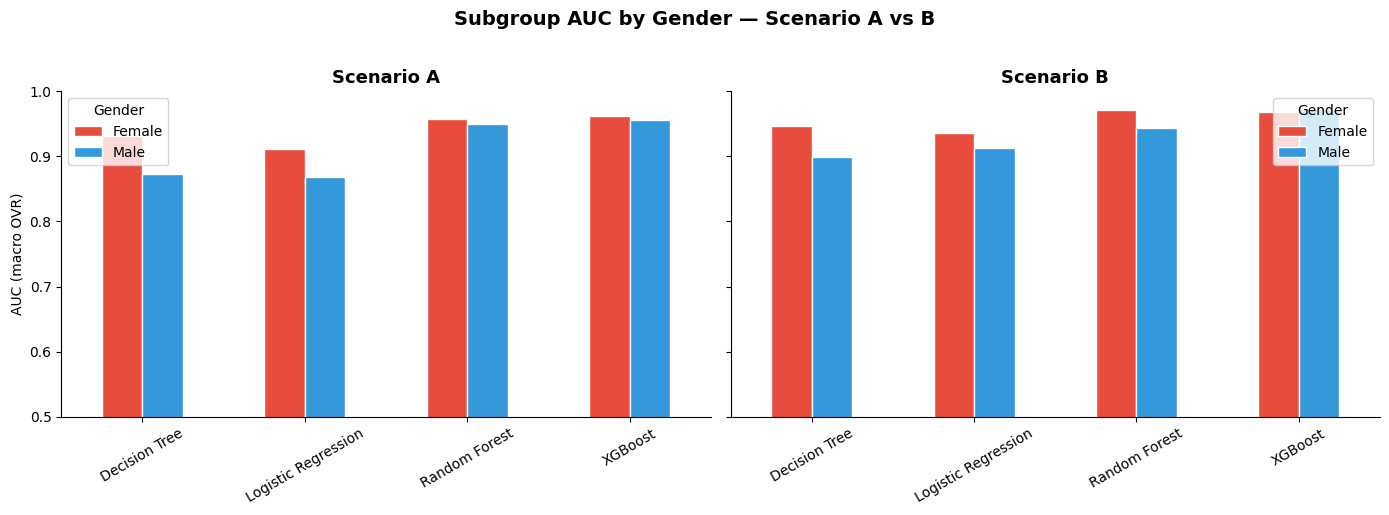

Saved: fairness_auc_gender.png


In [17]:
# ── Figure 1: AUC by Gender — Scenario A vs B ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, scen in enumerate(['A', 'B']):
    ax = axes[idx]
    scen_gender = fairness_df[
        (fairness_df['scenario'] == scen) & (fairness_df['group_type'] == 'Gender')
    ]
    
    pivot = scen_gender.pivot(index='classifier', columns='group', values='auc')
    pivot.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'], edgecolor='white')
    
    ax.set_title(f'Scenario {scen}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('AUC (macro OVR)' if idx == 0 else '')
    ax.set_ylim(0.5, 1.0)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Gender')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Subgroup AUC by Gender — Scenario A vs B', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'fairness_auc_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fairness_auc_gender.png')

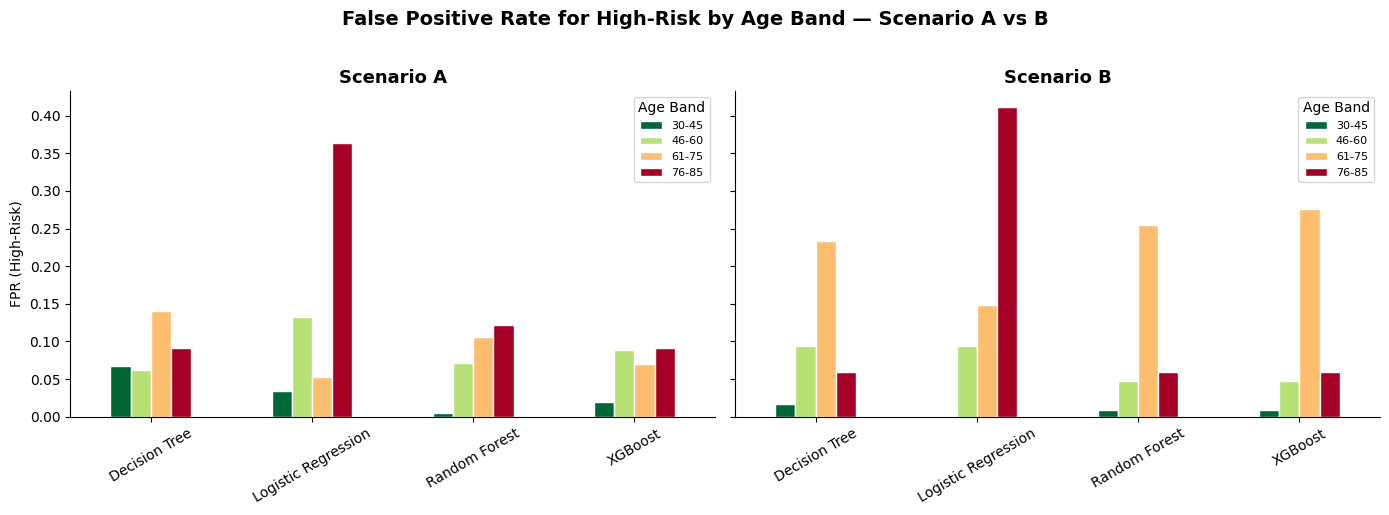

Saved: fairness_fpr_age_band.png


In [18]:
# ── Figure 2: FPR by Age Band — Scenario A vs B ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, scen in enumerate(['A', 'B']):
    ax = axes[idx]
    scen_age = fairness_df[
        (fairness_df['scenario'] == scen) & (fairness_df['group_type'] == 'Age Band')
    ]
    
    pivot = scen_age.pivot(index='classifier', columns='group', values='fpr_high')
    pivot.plot(kind='bar', ax=ax, edgecolor='white', cmap='RdYlGn_r')
    
    ax.set_title(f'Scenario {scen}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('FPR (High-Risk)' if idx == 0 else '')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Age Band', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('False Positive Rate for High-Risk by Age Band — Scenario A vs B',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'fairness_fpr_age_band.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fairness_fpr_age_band.png')

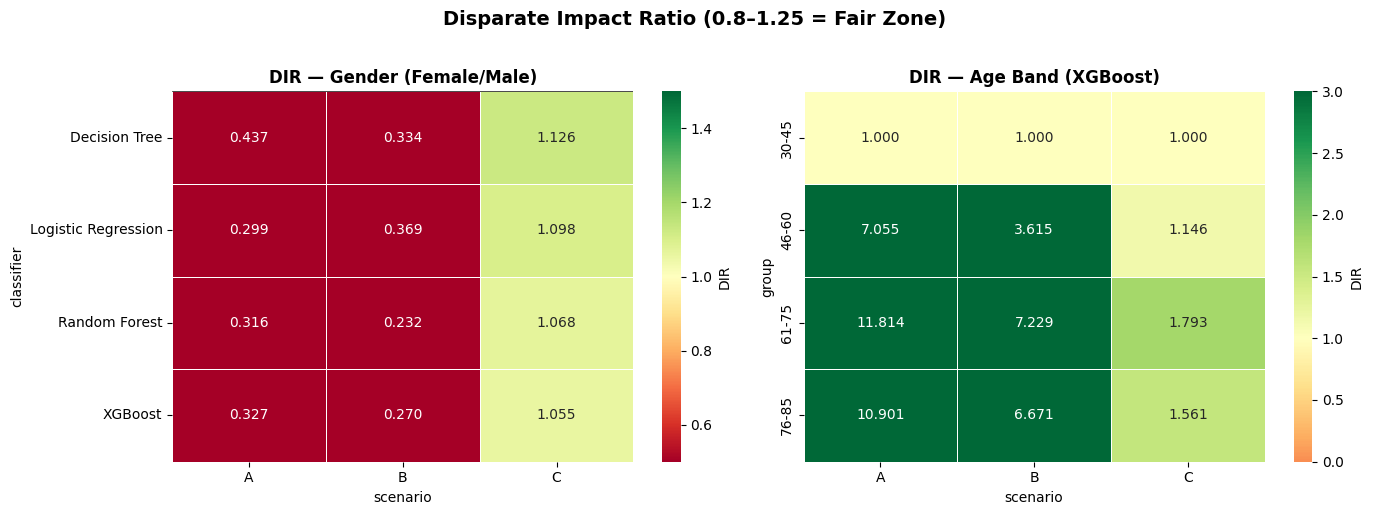

Saved: disparate_impact_heatmap.png


In [19]:
# ── Figure 3: Disparate Impact Ratio heatmap ─────────────────
# Show DIR for gender (Female vs Male) across all scenarios and classifiers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender DIR heatmap
ax = axes[0]
gender_dir_heat = gender_dir.pivot_table(
    index='classifier', columns='scenario', values='DIR'
)
sns.heatmap(gender_dir_heat, annot=True, fmt='.3f', cmap='RdYlGn',
            center=1.0, vmin=0.5, vmax=1.5,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'DIR'})
ax.set_title('DIR — Gender (Female/Male)', fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)

# Age band DIR heatmap (for best classifier only — to keep readable)
ax = axes[1]
# Find best classifier by overall F1 from Notebook 03 results
best_clf = 'XGBoost'  # update if your NB03 results differ
age_dir_best = age_dir[age_dir['classifier'] == best_clf]
age_dir_heat = age_dir_best.pivot_table(
    index='group', columns='scenario', values='DIR'
)
sns.heatmap(age_dir_heat, annot=True, fmt='.3f', cmap='RdYlGn',
            center=1.0, vmin=0.0, vmax=3.0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'DIR'})
ax.set_title(f'DIR — Age Band ({best_clf})', fontweight='bold')

plt.suptitle('Disparate Impact Ratio (0.8–1.25 = Fair Zone)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'disparate_impact_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: disparate_impact_heatmap.png')

## 7. Calibration Curves (Reliability Diagrams)

In insurance, premiums are priced from predicted **probabilities**, not just
binary classifications. A well-calibrated model produces probabilities that
match observed frequencies: if it predicts 30% risk, ~30% of those cases
should truly be high risk.

We plot calibration curves for the **High Risk class (class 2)** across
all classifiers for Scenarios A and B. This directly answers: *"Can we
trust this model's probability output for premium pricing?"*

We also report the **Brier score** per model (already computed in NB03,
recomputed here for the High-risk class specifically).

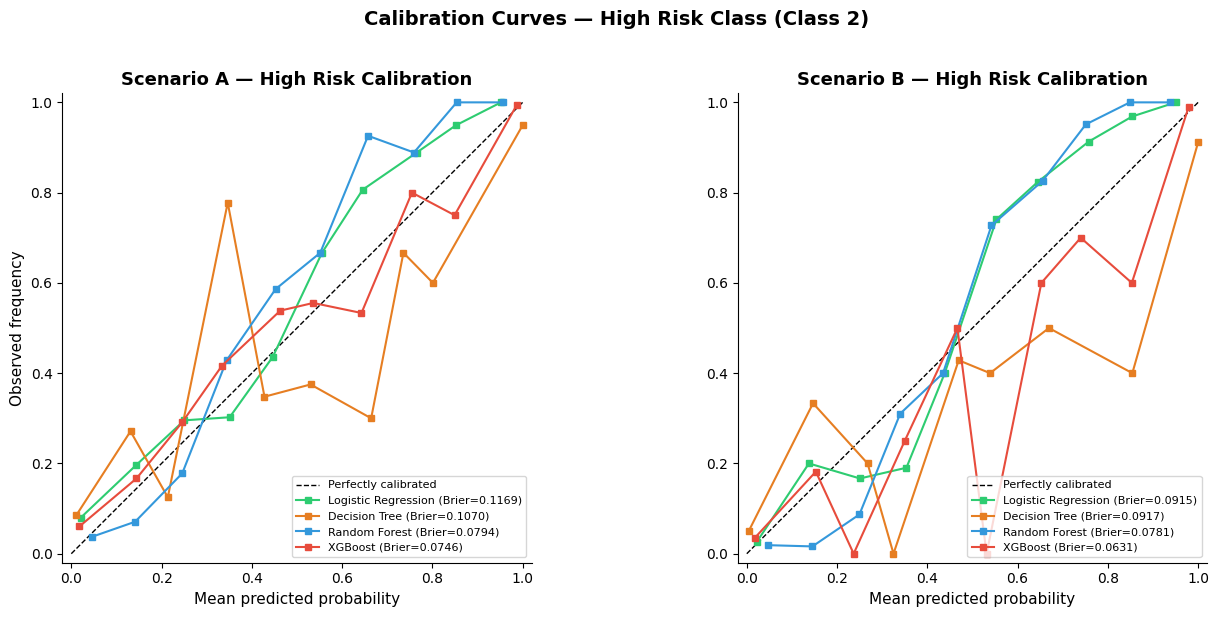

Saved: calibration_curves.png


In [20]:
# ── Calibration curves: Scenario A vs B, High-Risk class ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

clf_colors = {
    'Logistic Regression': '#2ecc71',
    'Decision Tree': '#e67e22',
    'Random Forest': '#3498db',
    'XGBoost': '#e74c3c'
}

for idx, scen in enumerate(['A', 'B']):
    ax = axes[idx]
    
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')
    
    for clf_name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']:
        key = (scen, clf_name)
        if key not in trained:
            continue
        
        info = trained[key]
        y_true = info['y_test']
        y_proba = info['y_proba']
        
        # Binary: is this participant High risk?
        y_true_binary = (y_true == 2).astype(int)
        y_proba_high = y_proba[:, 2]  # probability of class 2 (High)
        
        # Brier score for High class
        brier = brier_score_loss(y_true_binary, y_proba_high)
        
        # Calibration curve
        prob_true, prob_pred = calibration_curve(
            y_true_binary, y_proba_high, n_bins=10, strategy='uniform'
        )
        
        ax.plot(prob_pred, prob_true, 's-',
                color=clf_colors[clf_name],
                label=f'{clf_name} (Brier={brier:.4f})',
                linewidth=1.5, markersize=5)
    
    ax.set_xlabel('Mean predicted probability', fontsize=11)
    ax.set_ylabel('Observed frequency' if idx == 0 else '', fontsize=11)
    ax.set_title(f'Scenario {scen} — High Risk Calibration', fontweight='bold', fontsize=13)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Calibration Curves — High Risk Class (Class 2)',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: calibration_curves.png')

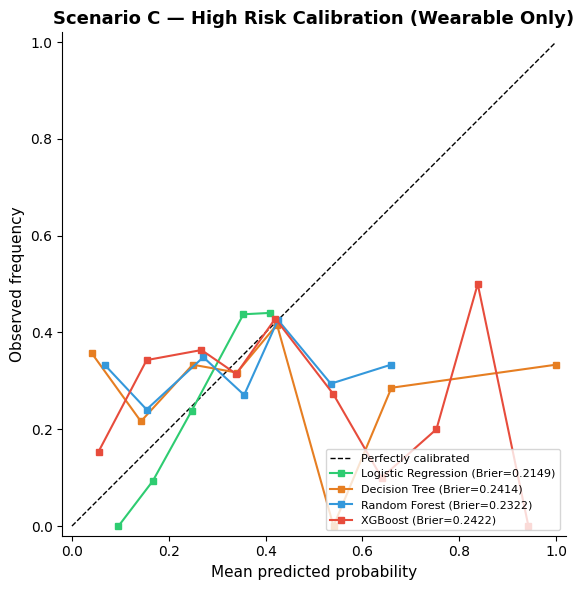

Saved: calibration_curves_scenario_c.png


In [21]:
# ── Calibration curve for Scenario C ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')

for clf_name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']:
    key = ('C', clf_name)
    if key not in trained:
        continue
    
    info = trained[key]
    y_true = info['y_test']
    y_proba = info['y_proba']
    
    y_true_binary = (y_true == 2).astype(int)
    y_proba_high = y_proba[:, 2]
    brier = brier_score_loss(y_true_binary, y_proba_high)
    
    prob_true, prob_pred = calibration_curve(
        y_true_binary, y_proba_high, n_bins=10, strategy='uniform'
    )
    
    ax.plot(prob_pred, prob_true, 's-',
            color=clf_colors[clf_name],
            label=f'{clf_name} (Brier={brier:.4f})',
            linewidth=1.5, markersize=5)

ax.set_xlabel('Mean predicted probability', fontsize=11)
ax.set_ylabel('Observed frequency', fontsize=11)
ax.set_title('Scenario C — High Risk Calibration (Wearable Only)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'calibration_curves_scenario_c.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: calibration_curves_scenario_c.png')

## 8. Brier Score Summary — High-Risk Class

Brier score measures the mean squared error of predicted probabilities.
Lower = better calibrated. This complements the visual calibration curves
with a single numeric metric per model.

In [22]:
# ── Brier score table for High-Risk class ───────────────────
brier_rows = []

for (scen, clf_name), info in trained.items():
    y_true = info['y_test']
    y_proba = info['y_proba']
    
    y_true_binary = (y_true == 2).astype(int)
    y_proba_high = y_proba[:, 2]
    brier = brier_score_loss(y_true_binary, y_proba_high)
    
    brier_rows.append({
        'Scenario': scen,
        'Classifier': clf_name,
        'Brier_High': brier
    })

brier_df = pd.DataFrame(brier_rows)
brier_pivot = brier_df.pivot_table(
    index='Classifier', columns='Scenario', values='Brier_High'
).round(4)

# Add B-A difference
if 'A' in brier_pivot.columns and 'B' in brier_pivot.columns:
    brier_pivot['B-A'] = brier_pivot['B'] - brier_pivot['A']

print('=' * 60)
print('BRIER SCORE — HIGH RISK CLASS (lower = better calibration)')
print('=' * 60)
print(brier_pivot)
print('\nNegative B-A means Scenario B is better calibrated than A.')

BRIER SCORE — HIGH RISK CLASS (lower = better calibration)
Scenario                 A      B      C     B-A
Classifier                                      
Decision Tree       0.1070 0.0917 0.2414 -0.0153
Logistic Regression 0.1169 0.0915 0.2149 -0.0254
Random Forest       0.0794 0.0781 0.2322 -0.0013
XGBoost             0.0746 0.0631 0.2422 -0.0115

Negative B-A means Scenario B is better calibrated than A.


## 9. Combined Fairness–Performance Summary

This is the **centrepiece table** for RQ3 — it shows, for each classifier × scenario,
the overall performance alongside fairness gaps and calibration quality.

In [23]:
# ── Build master summary table ───────────────────────────────
summary_rows = []

for (scen, clf_name), info in trained.items():
    y_true = info['y_test']
    y_pred = info['y_pred']
    y_proba = info['y_proba']
    
    # Overall metrics
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        y_bin = label_binarize(y_true, classes=[0, 1, 2])
        auc_macro = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
    except:
        auc_macro = np.nan
    
    brier_high = brier_score_loss((y_true == 2).astype(int), y_proba[:, 2])
    
    # Gender gap
    g_data = fairness_df[
        (fairness_df['scenario'] == scen) & 
        (fairness_df['classifier'] == clf_name) &
        (fairness_df['group_type'] == 'Gender')
    ]
    if len(g_data) >= 2:
        gender_auc_gap = g_data['auc'].max() - g_data['auc'].min()
        gender_fpr_gap = g_data['fpr_high'].max() - g_data['fpr_high'].min()
    else:
        gender_auc_gap = np.nan
        gender_fpr_gap = np.nan
    
    # Age band gap
    a_data = fairness_df[
        (fairness_df['scenario'] == scen) & 
        (fairness_df['classifier'] == clf_name) &
        (fairness_df['group_type'] == 'Age Band')
    ]
    if len(a_data) >= 2:
        age_auc_gap = a_data['auc'].max() - a_data['auc'].min()
        age_fpr_gap = a_data['fpr_high'].max() - a_data['fpr_high'].min()
    else:
        age_auc_gap = np.nan
        age_fpr_gap = np.nan
    
    # Gender DIR
    g_dir = dir_df[
        (dir_df['scenario'] == scen) & 
        (dir_df['classifier'] == clf_name) &
        (dir_df['group'] == 'Female')
    ]
    gender_dir_val = g_dir['DIR'].values[0] if len(g_dir) > 0 else np.nan
    
    summary_rows.append({
        'Scenario': scen,
        'Classifier': clf_name,
        'F1_macro': f1_macro,
        'AUC_macro': auc_macro,
        'Brier_High': brier_high,
        'Gender_AUC_gap': gender_auc_gap,
        'Gender_FPR_gap': gender_fpr_gap,
        'Age_AUC_gap': age_auc_gap,
        'Age_FPR_gap': age_fpr_gap,
        'Gender_DIR': gender_dir_val
    })

summary_df = pd.DataFrame(summary_rows)

print('=' * 100)
print('COMBINED FAIRNESS–PERFORMANCE SUMMARY (RQ3)')
print('=' * 100)
print(summary_df.to_string(index=False))

COMBINED FAIRNESS–PERFORMANCE SUMMARY (RQ3)
Scenario          Classifier  F1_macro  AUC_macro  Brier_High  Gender_AUC_gap  Gender_FPR_gap  Age_AUC_gap  Age_FPR_gap  Gender_DIR
       A Logistic Regression    0.7368     0.9036      0.1169          0.0430          0.1169       0.0856       0.3300      0.2985
       A       Decision Tree    0.7931     0.9125      0.1070          0.0584          0.0321       0.0900       0.0784      0.4373
       A       Random Forest    0.8514     0.9641      0.0794          0.0074          0.0929       0.0368       0.1164      0.3164
       A             XGBoost    0.8711     0.9678      0.0746          0.0054          0.1060       0.0327       0.0717      0.3275
       B Logistic Regression    0.7749     0.9333      0.0915          0.0232          0.0199       0.0577       0.4118      0.3694
       B       Decision Tree    0.8408     0.9338      0.0917          0.0471          0.1227       0.1063       0.2169      0.3337
       B       Random Forest    

In [24]:
# ── Save summary for report ──────────────────────────────────
summary_df.to_csv(RESULTS_PATH + 'fairness_summary.csv', index=False)
fairness_df.to_csv(RESULTS_PATH + 'fairness_subgroup_detail.csv', index=False)
dir_df.to_csv(RESULTS_PATH + 'disparate_impact.csv', index=False)
brier_df.to_csv(RESULTS_PATH + 'brier_high_risk.csv', index=False)

print('Saved to results/:')
print('  fairness_summary.csv')
print('  fairness_subgroup_detail.csv')
print('  disparate_impact.csv')
print('  brier_high_risk.csv')

Saved to results/:
  fairness_summary.csv
  fairness_subgroup_detail.csv
  disparate_impact.csv
  brier_high_risk.csv


## 10. Key Findings for Report

In [25]:
print('=' * 80)
print('KEY FINDINGS — NOTEBOOK 05')
print('=' * 80)

# 1. Best performing model
best_row = summary_df.loc[summary_df['F1_macro'].idxmax()]
print(f'\n1. BEST OVERALL MODEL')
print(f'   {best_row["Classifier"]} / Scenario {best_row["Scenario"]}')
print(f'   F1={best_row["F1_macro"]:.4f}, AUC={best_row["AUC_macro"]:.4f}')

# 2. Fairest model (smallest combined gap)
summary_df['total_gap'] = (
    summary_df['Gender_AUC_gap'].fillna(0) + 
    summary_df['Age_AUC_gap'].fillna(0) + 
    summary_df['Gender_FPR_gap'].fillna(0) + 
    summary_df['Age_FPR_gap'].fillna(0)
)
fairest_row = summary_df.loc[summary_df['total_gap'].idxmin()]
print(f'\n2. FAIREST MODEL (smallest combined AUC + FPR gap)')
print(f'   {fairest_row["Classifier"]} / Scenario {fairest_row["Scenario"]}')
print(f'   Gender AUC gap: {fairest_row["Gender_AUC_gap"]:.4f}')
print(f'   Age AUC gap: {fairest_row["Age_AUC_gap"]:.4f}')

# 3. Best calibrated model
best_cal_row = summary_df.loc[summary_df['Brier_High'].idxmin()]
print(f'\n3. BEST CALIBRATED MODEL (lowest Brier score, High-Risk class)')
print(f'   {best_cal_row["Classifier"]} / Scenario {best_cal_row["Scenario"]}')
print(f'   Brier = {best_cal_row["Brier_High"]:.4f}')

# 4. DIR violations
all_unfair = dir_df[dir_df['fair'] == False]
print(f'\n4. DISPARATE IMPACT VIOLATIONS (DIR outside 0.8–1.25)')
print(f'   Total violations: {len(all_unfair)} out of {len(dir_df)} subgroup checks')
if len(all_unfair) > 0:
    print('   Violations:')
    for _, row in all_unfair.iterrows():
        print(f'     {row["classifier"]} / Scenario {row["scenario"]} / '
              f'{row["group_type"]}={row["group"]}: DIR={row["DIR"]:.3f}')

# 5. Wearable impact on fairness (A vs B comparison)
print(f'\n5. WEARABLE IMPACT ON FAIRNESS (Scenario B vs A)')
for clf_name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']:
    a_row = summary_df[(summary_df['Scenario'] == 'A') & (summary_df['Classifier'] == clf_name)]
    b_row = summary_df[(summary_df['Scenario'] == 'B') & (summary_df['Classifier'] == clf_name)]
    if len(a_row) > 0 and len(b_row) > 0:
        gap_change = b_row['Gender_AUC_gap'].values[0] - a_row['Gender_AUC_gap'].values[0]
        direction = 'narrowed (fairer)' if gap_change < 0 else 'widened (less fair)'
        print(f'   {clf_name:25s}: Gender AUC gap {direction} by {abs(gap_change):.4f}')

# 6. RQ3 recommendation
print(f'\n6. RQ3 RECOMMENDATION')
# Find model with best performance–fairness balance
# Simple heuristic: rank by F1 then penalise for large gaps
summary_df['balance_score'] = (
    summary_df['F1_macro'] * 0.4 +
    summary_df['AUC_macro'].fillna(0) * 0.3 -
    summary_df['total_gap'] * 0.2 -
    summary_df['Brier_High'] * 0.1
)
best_balance = summary_df.loc[summary_df['balance_score'].idxmax()]
print(f'   Best performance–fairness–calibration balance:')
print(f'   {best_balance["Classifier"]} / Scenario {best_balance["Scenario"]}')
print(f'   F1={best_balance["F1_macro"]:.4f}, AUC={best_balance["AUC_macro"]:.4f}, '
      f'Brier={best_balance["Brier_High"]:.4f}')
print(f'   Gender AUC gap={best_balance["Gender_AUC_gap"]:.4f}, '
      f'Age AUC gap={best_balance["Age_AUC_gap"]:.4f}')

KEY FINDINGS — NOTEBOOK 05

1. BEST OVERALL MODEL
   XGBoost / Scenario B
   F1=0.8816, AUC=0.9760

2. FAIREST MODEL (smallest combined AUC + FPR gap)
   XGBoost / Scenario A
   Gender AUC gap: 0.0054
   Age AUC gap: 0.0327

3. BEST CALIBRATED MODEL (lowest Brier score, High-Risk class)
   XGBoost / Scenario B
   Brier = 0.0631

4. DISPARATE IMPACT VIOLATIONS (DIR outside 0.8–1.25)
   Total violations: 40 out of 72 subgroup checks
   Violations:
     Logistic Regression / Scenario A / Gender=Female: DIR=0.299
     Logistic Regression / Scenario A / Age Band=46-60: DIR=5.882
     Logistic Regression / Scenario A / Age Band=61-75: DIR=8.361
     Logistic Regression / Scenario A / Age Band=76-85: DIR=11.400
     Decision Tree / Scenario A / Gender=Female: DIR=0.437
     Decision Tree / Scenario A / Age Band=46-60: DIR=2.876
     Decision Tree / Scenario A / Age Band=61-75: DIR=5.254
     Decision Tree / Scenario A / Age Band=76-85: DIR=5.128
     Random Forest / Scenario A / Gender=Female

In [26]:
print('\nNotebook 05 complete.')
print('\nOutputs generated:')
print('  Figures: fairness_auc_gender.png, fairness_fpr_age_band.png,')
print('           disparate_impact_heatmap.png, calibration_curves.png,')
print('           calibration_curves_scenario_c.png')
print('  CSVs:    fairness_summary.csv, fairness_subgroup_detail.csv,')
print('           disparate_impact.csv, brier_high_risk.csv')
print('\nNext: Write final report using results from Notebooks 03, 04, and 05.')


Notebook 05 complete.

Outputs generated:
  Figures: fairness_auc_gender.png, fairness_fpr_age_band.png,
           disparate_impact_heatmap.png, calibration_curves.png,
           calibration_curves_scenario_c.png
  CSVs:    fairness_summary.csv, fairness_subgroup_detail.csv,
           disparate_impact.csv, brier_high_risk.csv

Next: Write final report using results from Notebooks 03, 04, and 05.
